# Title & Overview
# Quark vs Gluon Jet Classification using Graph Neural Networks

This notebook implements **Task 2** of the ML4SCI GSoC test.

Goal:
Convert jet images into graph representations and train a Graph Neural Network (GNN) to classify **quark jets vs gluon jets**.

Pipeline:

Jet Image → Point Cloud → Graph Construction → GNN → Evaluation

In [ ]:
import h5py
import numpy as np
import torch
import matplotlib.pyplot as plt
import networkx as nx

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, global_mean_pool
from torch_geometric.nn import knn_graph

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve

## Load data from HDF5

In [1]:
x = torch.rand(10000,10000).cuda()
y = torch.matmul(x,x)
print("GPU computation done")

GPU computation done


In [2]:
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Torch version: 2.5.1+cu121
CUDA available: True
GPU: NVIDIA GeForce RTX 3050 A Laptop GPU


## Dataset

The dataset consists of jet images with three detector channels:

- ECAL (Electromagnetic calorimeter)
- HCAL (Hadronic calorimeter)
- Track information

Each jet image has shape:

(3, 120, 120)

In [4]:
file_path = r"C:\quark_gluon_dataset.hdf5"

h5_file = h5py.File(file_path, "r")
X = h5_file["X_jets"][:8000]
y = h5_file["y"][:8000]

X = np.transpose(X, (0, 3, 1, 2))
X = X[:, :, :120, :120]

In [5]:
print(X.shape)


(8000, 3, 120, 120)


## Image to Point Cloud Conversion

Only **non-zero pixels** correspond to particle activity.

Each active pixel becomes a node with features:

[x_position, y_position, ECAL, HCAL, Track]

In [46]:
def image_to_pointcloud(image):
    coords = np.argwhere(image.sum(axis=0) > 0)
    nodes = []
    for x, y in coords:
        ecal  = image[0, x, y]
        hcal  = image[1, x, y]
        track = image[2, x, y]
        nodes.append([
            x/120,
            y/120,
            ecal,
            hcal,
            track
        ])
    return np.array(nodes)

## Graph Construction

Edges are created using **k-nearest neighbors (k=8)** based on spatial coordinates.

In [47]:
def build_graph(nodes, k=8):
    x = torch.tensor(nodes, dtype=torch.float32)
    edge_index = knn_graph(x[:, :2], k=k)
    return x, edge_index

## Graph Object Creation

In [48]:
def create_graph(nodes , label):
    x, edge_index = build_graph(nodes)
    data = Data(
        x=x,
        edge_index=edge_index,
        y=torch.tensor([int(label)], dtype=torch.long)
    )
    return data

## Build Graph Dataset

In [49]:
graphs = []
for i in range(len(X)):
    nodes = image_to_pointcloud(X[i])
    if len(nodes) < 5:
        continue
    graph = create_graph(nodes, y[i])
    graphs.append(graph)
print("Total graphs:", len(graphs))

Total graphs: 8000


## Train/Test Split

In [32]:
!pip install scikit-learn   

  Using cached scipy-1.17.1-cp312-cp312-win_amd64.whl.metadata (60 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.0 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.0 MB 1.4 MB/s eta 0:00:06
   --- ------------------------------------ 0.8/8.0 MB 1.2 MB/s eta 0:00:06
   ----- ---------------------------------- 1.0/8.0 MB 1.3 MB/s eta 0:00:06
   ------ --------------------------------- 1.3/8.0 MB 1.2 MB/s eta 0:00:06
   ------ --------------------------------- 1.3/8.0 MB 1.2 MB/s eta 0:00:06
   ------- -------------------------------- 1.6/8.0 MB 1.1 MB/s eta 0:00:06
   --------- ------------------------------ 1.8/8.0 MB 1.2 MB/s eta 0:00:06
   ---------- ----------------------------- 2.1/8.0 MB 1.2


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [50]:
from sklearn.model_selection import train_test_split
train_graph , test_graph =train_test_split(graphs, test_size = 0.2 , random_state = 42) 

## Graph DataLoader

In [51]:
from torch_geometric.loader import DataLoader
train_loader = DataLoader(train_graph , batch_size = 32 , shuffle = True)
test_loader = DataLoader(test_graph , batch_size = 32)

# Build GNN Model

## Graph Neural Network Architecture

We use a **3-layer Graph Convolution Network (GCN)** followed by global pooling.

In [52]:
from torch_geometric.nn import GCNConv, global_mean_pool
import torch.nn.functional as F

class JetGNN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = GCNConv(5, 64)
        self.conv2 = GCNConv(64, 128)
        self.conv3 = GCNConv(128, 128)

        self.fc1 = torch.nn.Linear(128, 64)
        self.fc2 = torch.nn.Linear(64, 2)

    def forward(self, x, edge_index, batch):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = self.conv3(x, edge_index)
        x = F.relu(x)
        x = global_mean_pool(x, batch)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

# Defining of model and optimizers

In [53]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = JetGNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Train the GNN

In [54]:
for epoch in range(50):
    model.train()
    total_loss = 0
    for data in train_loader:
        data = data.to(device)
        optimizer.zero_grad()
        out = model(data.x , data.edge_index , data.batch)
        loss = F.cross_entropy(out, data.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss {total_loss/len(train_loader):.4f}")

Epoch 1, Loss 0.6937
Epoch 2, Loss 0.6933
Epoch 3, Loss 0.6932
Epoch 4, Loss 0.6934
Epoch 5, Loss 0.6930
Epoch 6, Loss 0.6929
Epoch 7, Loss 0.6694
Epoch 8, Loss 0.6032
Epoch 9, Loss 0.5981
Epoch 10, Loss 0.5949
Epoch 11, Loss 0.5947
Epoch 12, Loss 0.5957
Epoch 13, Loss 0.5929
Epoch 14, Loss 0.5927
Epoch 15, Loss 0.5942
Epoch 16, Loss 0.5913
Epoch 17, Loss 0.5903
Epoch 18, Loss 0.5888
Epoch 19, Loss 0.5851
Epoch 20, Loss 0.5895
Epoch 21, Loss 0.5875
Epoch 22, Loss 0.5841
Epoch 23, Loss 0.5836
Epoch 24, Loss 0.5856
Epoch 25, Loss 0.5830
Epoch 26, Loss 0.5849
Epoch 27, Loss 0.5817
Epoch 28, Loss 0.5833
Epoch 29, Loss 0.5831
Epoch 30, Loss 0.5812
Epoch 31, Loss 0.5805
Epoch 32, Loss 0.5805
Epoch 33, Loss 0.5820
Epoch 34, Loss 0.5804
Epoch 35, Loss 0.5803
Epoch 36, Loss 0.5800
Epoch 37, Loss 0.5793
Epoch 38, Loss 0.5795
Epoch 39, Loss 0.5809
Epoch 40, Loss 0.5806
Epoch 41, Loss 0.5789
Epoch 42, Loss 0.5796
Epoch 43, Loss 0.5816
Epoch 44, Loss 0.5789
Epoch 45, Loss 0.5793
Epoch 46, Loss 0.57

# Evaluate Performance (ROC-AUC)
ROC-AUC in scikit-learn (sklearn) is a metric that quantifies the performance of a binary or multiclass classifier by measuring the Area Under the Receiver Operating Characteristic (ROC) Curve

In [57]:
from sklearn.metrics import roc_auc_score
model.eval()
preds= []
labels = []
with torch.no_grad():
    for data in test_loader:
        data = data.to(device)
        out = model(data.x, data.edge_index, data.batch)
        prob =torch.softmax(out , dim = 1)[:,1]
        preds.extend(prob.cpu().numpy())
        labels.extend(data.y.cpu().numpy())
auc = roc_auc_score(labels, preds)
print("ROC-AUC:", auc)

ROC-AUC: 0.7522064155594781


HDF5 dataset
      -->
image_to_pointcloud
      -->
build_graph (kNN)
      -->
PyTorch Geometric Data
      -->
Graph Dataset
      -->
GNN Model
      -->
ROC-AUC Evaluation

### The Graph Neural Network successfully learns structural information from jet graphs. Training converges around a loss of ~0.58 and the model achieves a ROC-AUC of 0.75, indicating strong separation between quark and gluon jets.

## ROC curve

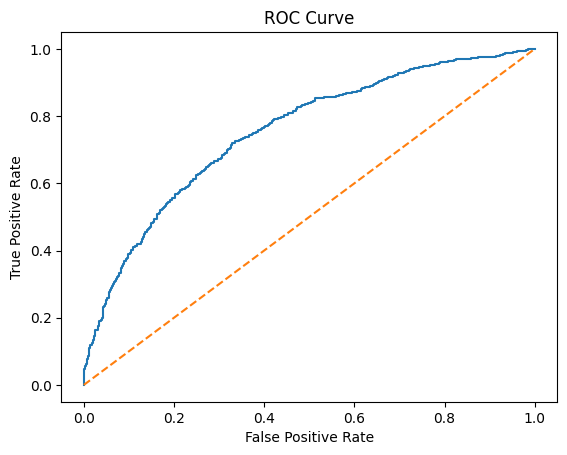

In [61]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(labels, preds)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

# Visualize One Jet Graph (very good for submission)

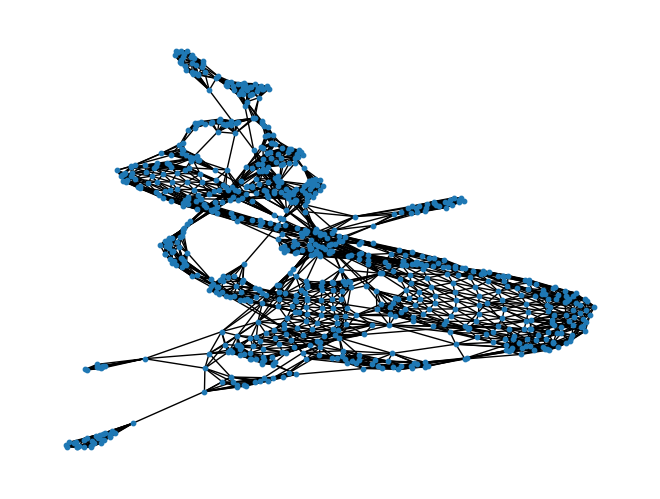

In [59]:
import networkx as nx

g = graphs[0]

edge_list = g.edge_index.numpy()

G = nx.Graph()
G.add_edges_from(edge_list.T)

nx.draw(G, node_size=10)
plt.show()

## Results

The GNN successfully captures spatial and energy relationships between detector cells.

Training stabilizes around loss ≈ 0.58 and the model achieves **ROC-AUC ≈ 0.75**, demonstrating strong discrimination between quark and gluon jets.

Future improvements could include:

• Graph attention networks  
• Edge feature learning  
• Contrastive representation learning